## Exercice 1

In [1]:
def AfficheSousSequences(T):
    Tt = [[T[0]]]
    for e in T[1:]:
        if e >= Tt[-1][-1]:
            Tt[-1].append(e)
        else:
            Tt.append([e])
    Tt = str(Tt)
    Tt = Tt.replace('], [','>;<')
    Tt = Tt[1:-1].replace('[','<')
    Tt = Tt.replace(']','>')
    return Tt

In [2]:
T = [1, 2, 5, 3, 12, 25, 13, 8, 4, 7, 24, 28, 32, 11, 14]
AfficheSousSequences(T)

'<1, 2, 5>;<3, 12, 25>;<13>;<8>;<4, 7, 24, 28, 32>;<11, 14>'

## Exercice 2:

In [3]:
def Intersection(T1, T2):
    T = []
    if len(T1)>0 and len(T2)>0:
        for t1 in T1:
            if t1 in T2:
                T.append(t1)
    return T

In [4]:
T1=[0, 3 , 6, 8, 26, 19,33, 5, 11]
T2=[0, 3 , 8, 16, 12,33]
Intersection(T1,T2)

[0, 3, 8, 33]

In [5]:
def Complement(T):
    C = []
    if len(T)>0:
        max = T[-1]
    else:
        max = 0
    for e in range(max):
        if e not in T:
            C.append(e)
    return C

In [6]:
T = [0, 1, 2, 3, 6, 8, 9, 11, 14, 15, 17, 18]
Complement(T)

[4, 5, 7, 10, 12, 13, 16]

In [7]:
def Fusion(T1,T2):
    T3 = []
    if len(T1)==0:
        T3 = T1
    elif len(T2)==0:
        T3 = T2
    else:
        T3 = list(set(T1 + T2))
        T3.sort()
    return T3

In [8]:
def FusionV2(T1,T2):
    for e in T1:
        if e not in T2:
            T2.append(e)
    T2.sort()
    return T2

In [9]:
T1=[3 , 6, 8, 26, 109,133, 165, 181]
T2=[3 , 8, 109, 112,303]
print(Fusion(T1,T2))
print(FusionV2(T1,T2))

[3, 6, 8, 26, 109, 112, 133, 165, 181, 303]
[3, 6, 8, 26, 109, 112, 133, 165, 181, 303]


## Exercice 3:

In [10]:
def frequence(T):
    F = []
    for e in set(T):
        F.append((e,T.count(e)))
    return F

In [11]:
T = [9, 4, 5, 6, 7, 8, 1, 2, 6, 7, 8, 8, 10, 4, 6, 0, 1, 2, 3, 4, 5]
frequence(T)

[(0, 1),
 (1, 2),
 (2, 2),
 (3, 1),
 (4, 3),
 (5, 2),
 (6, 3),
 (7, 2),
 (8, 3),
 (9, 1),
 (10, 1)]

## Exercice 4: Compression de donnés

In [12]:
def fibo(n):
    if n == 0 or n == 1:
        return 1
    else:
        return fibo(n-1) + fibo(n-2)

In [13]:
def fibo_iter(n):
    a, b = 1, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

In [14]:
n = 10
print(fibo_iter(n))
print(fibo(n))

89
89


In [15]:
def SuiteFibo(n):
    L = [[],[]]
    for i in range(1,n+1):
        if fibo_iter(i) <= n:
            L[0].append(fibo_iter(i))
            L[1].append(0)
        else:
            break
    return L

In [16]:
SuiteFibo(50)

[[1, 2, 3, 5, 8, 13, 21, 34], [0, 0, 0, 0, 0, 0, 0, 0]]

In [17]:
def coder(n):
    L = SuiteFibo(n)
    r = n
    L[0].reverse()
    for l in L[0]:
        if r == 0: break
        if (r-l) >= 0:
            index = L[0].index(l)
            L[1][index] = 1
            r -= l
    L[0].reverse()
    L[1].reverse()
    return L
    

In [18]:
coder(50)

[[1, 2, 3, 5, 8, 13, 21, 34], [0, 0, 1, 0, 0, 1, 0, 1]]

In [19]:
def decoder(X):
    l = []
    for i in range(1,len(X)+1):
        l.append(fibo_iter(i))
    L = list(map(lambda a,b: a*b, X, l))
    return sum(L)
    

In [20]:
X = [0, 0, 1, 0, 0, 1, 0, 1]
decoder(X)

50

## Exercice 5

In [21]:
Temperature ={
    "Maroc" : [39, 28, 34, 43, 39, 34, 29, 34, 25, 26, 30, 34],
    "Espagne": [28, 25, 34, 34, 34, 32, 22, 25, 27, 34, 24, 24],
    "France" : [26, 20, 24, 31, 33, 29, 34, 33, 33, 32, 34, 28]
}

Mois = [ "janvier", "février", "mars", "avril", "mai", "juin", "juillet", "août", "septembre", "octobre", "novembre", "décembre"]

In [22]:
# Question 1.1
print("La température au Maroc en février est:",Temperature["Maroc"][1])

La température au Maroc en février est: 28


In [23]:
# Question 1.2
def AfficheMois(mois_choisi):
    Tem_mois = []
    index = Mois.index(mois_choisi.lower())
    for pays in Temperature:
        Tem_mois.append([pays,Temperature[pays][index]])
    return Tem_mois


AfficheMois("janvier")

[['Maroc', 39], ['Espagne', 28], ['France', 26]]

In [24]:
# Question 1.3
def AjoutPays(pays,Temp):
    Temperature[pays] = Temp

AjoutPays("Italie",[30, 28, 25, 27, 29, 32, 34, 33, 31, 28, 26, 24])
Temperature

{'Maroc': [39, 28, 34, 43, 39, 34, 29, 34, 25, 26, 30, 34],
 'Espagne': [28, 25, 34, 34, 34, 32, 22, 25, 27, 34, 24, 24],
 'France': [26, 20, 24, 31, 33, 29, 34, 33, 33, 32, 34, 28],
 'Italie': [30, 28, 25, 27, 29, 32, 34, 33, 31, 28, 26, 24]}

In [25]:
def ModificationPaysMois(pays,mois,val_temp):
    index = Mois.index(mois.lower())
    Temperature[pays][index] = val_temp

## Exercice 6

In [26]:
import matplotlib.pyplot as plt

def tracer_chemin(points, style='o-', title = "Titles", XTitle = "X", YTitle = "Y"):
    for ligne in points:
        x = [point[0] for point in ligne]
        y = [point[1] for point in ligne]
        plt.plot(x, y, style)
    
    plt.title(title)
    plt.xticks(range(int(min(x)), int(max(x)) + 2, 1))
    plt.yticks(range(int(min(y)), int(max(y)) + 2, 1))
    plt.xlabel(XTitle)
    plt.ylabel(YTitle)
    plt.grid(True)
    plt.show()

In [27]:
def sign(A,B):
    if A[0] < B[0]:
        Xi = 1
    else:
        Xi = -1
    if A[1] < B[1]:
        Yi = 1
    else:
        Yi = -1
    return (Xi,Yi)


In [28]:
def cheminHV(A,B):
    (Xi,Yi) = sign(A,B)
    HVAB = []
    # X
    HVAB.append(A)
    while A[0] != B[0]:
        A = (A[0]+Xi,A[1])
        HVAB.append(A)
    # Y
    while A[1] != B[1]:
        A = (A[0],A[1]+Yi)
        HVAB.append(A)
    return HVAB

[(2, 6), (3, 6), (4, 6), (4, 5), (4, 4), (4, 3)]


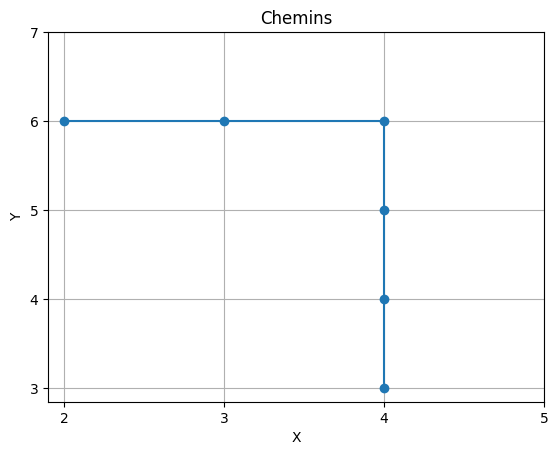

In [45]:
A = (2,6)
B = (4,3)
print(cheminHV(A,B))
tracer_chemin([cheminHV(A,B)],style="o-",title = "Chemins")

In [46]:
DictChemins  = {
    'C1' : [(2, 6), (3, 6), (4, 6), (4, 5), (4, 4), (4, 3)] , 
    'C2' : [(2, 6), (2, 5), (2, 4), (2, 3), (2, 2), (3, 2), (3, 3), (4,3)] , 
    'C3' : [(2, 6), (2, 5), (2, 4), (3, 4), (3, 3), (4, 3)] , 
    'C4' : [(2, 6), (1, 6), (0, 6), (0, 5), (0, 4), (0, 3), (1, 3), (2, 3), (3, 3), (4, 3)]
}

In [47]:
def distanceChemin(cle):
    return len(DictChemins[cle])

In [48]:
def distanceMinimale(DictChm):
    return min([len(DictChm[chm]) for chm in DictChm])

In [49]:
def cheminMinimal(DictChm):
    DMin = distanceMinimale(DictChm)
    for chm in DictChm:
        if len(DictChm[chm]) == DMin:
            return DictChm[chm]

In [50]:
def cheminRetour(C):
    C.reverse()
    return C

In [51]:
chMin = cheminMinimal(DictChemins)
chMinRev = cheminRetour(cheminMinimal(DictChemins))
print(chMin)
print(chMinRev)

[(4, 3), (4, 4), (4, 5), (4, 6), (3, 6), (2, 6)]
[(4, 3), (4, 4), (4, 5), (4, 6), (3, 6), (2, 6)]


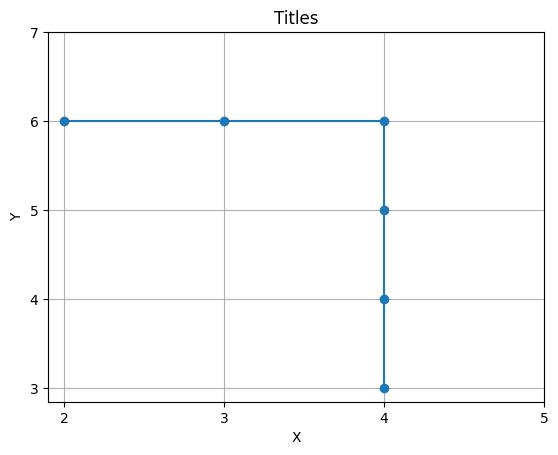

In [52]:
tracer_chemin([chMin])